# Part 1

In [29]:
import numpy as np
import matplotlib.pyplot as plt

'''
States:
0: After surgery
1: Local recurrence
2: Distant metastasis
3: Local and distant recurrence
4: Death

One time step is 1 month. 

'''


# Transition matrix
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001], 
              [0, 0.986, 0.005, 0.004, 0.005], 
              [0, 0, 0.992, 0.003, 0.005], 
              [0, 0, 0, 0.991, 0.009], 
              [0, 0, 0, 0, 1]])

print("Transition Matrix P:\n")
print(P)

Transition Matrix P:

[[0.9915 0.005  0.0025 0.     0.001 ]
 [0.     0.986  0.005  0.004  0.005 ]
 [0.     0.     0.992  0.003  0.005 ]
 [0.     0.     0.     0.991  0.009 ]
 [0.     0.     0.     0.     1.    ]]


## Task 1

In [30]:
np.random.seed(5)

# Simulating 1000 woman
N = 1000
# States for all 1000 woman
states = np.zeros(N, dtype=int)
# All starting in state 0 (after surgery)
states[:] = 0
# Initialize a list to include state history (i.e. state-vector for each time step)
state_history = [states.copy()]
# Number of states
num_states = len(P)
# Initial time, starting in 1 to avoid having death at time 0
t = 1

# simulate until all women are in state 4 (death)
while not np.all(states == 4): 

    # Looping through all women
    for i in range(N):
        # current state for woman i
        current_state = states[i]

        # Only update state if this woman is not dead
        if current_state != 4:

            # Transition probabilities for current state
            transition_probs = P[current_state]
            # Next state 
            next_state = np.random.choice(num_states, p=transition_probs)
            # Update state for woman i
            states[i] = next_state
        
    # Increment in time after updating states for all women
    t += 1
    # Append current states to history
    state_history.append(states.copy())

# Print final time step
print(f"All women have died after {t} months ~ {t // 12} years and {t % 12} months.")


# Convert state history to a numpy array 
state_history = np.array(state_history)

print("State history shape:", state_history.shape)
#print("State history (last 5 time steps):\n", state_history[-5:])

All women have died after 1046 months ~ 87 years and 2 months.
State history shape: (1046, 1000)


(1000,)


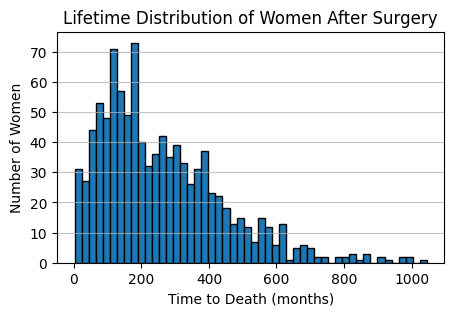

Mean death time (months): 259.737 ~ 21.0 years
Standard deviation of death time (months): 183.9528630682328 ~ 15.0 years


In [31]:
# Simmurizing the lifetime distribution of the women after surgery

# For every woman, find the time step at which she dies (state 4)
death_times = np.zeros(N, dtype=int)
for i in range(N):
    # Find the first time step for every woman (column) where the state = 4
    death_times[i] = np.where(state_history[:, i] == 4)[0][0]

# Should contain 1000 deaths times 
print(death_times.shape)

# Plotting the lifetime distribution
plt.figure(figsize=(5, 3))
plt.hist(death_times, bins=50, edgecolor='black')
plt.title('Lifetime Distribution of Women After Surgery')
plt.xlabel('Time to Death (months)')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Mean death time (months):", np.mean(death_times), "~", np.mean(death_times) // 12, "years")
print("Standard deviation of death time (months):", np.std(death_times), "~", np.std(death_times) // 12, "years")

## Task 2

In [32]:
# Now we look at a specific t-value, t=120
from scipy import stats
n_women = 1000
t = 120

def specific_t(P, n_women):

    counts = np.zeros(5)

    for _ in range(n_women):

        # Initialize state
        state = 0

        for _ in range(t):

            state = np.random.choice(5,p=P[state])

        counts[state] += 1

    empirical = counts / n_women

    # # Initialize the initial state distribution
    p0 = np.array([1,0,0,0,0])

    # # Theoretical value
    theoretical = (p0@ np.linalg.matrix_power(P, t))

    print("Empirical:")
    print(empirical)

    print("\nTheoretical:")
    print(theoretical)

    # Chi-square GOF test
    expected_counts = (theoretical * n_women)

    print("\nExpected values:")
    print(expected_counts)

    print("\nObserved values:")
    print(counts)

    n_bins_chi2 = 5

    chi2_test = 0

    for i in range(n_bins_chi2):

        chi2_test += ((counts[i] - expected_counts[i])**2/expected_counts[i])

    df = n_bins_chi2 - 1

    p_val = (1-stats.chi2.cdf(x=chi2_test,df=df))

    print("\nChi-square GOF results:")
    print(f"df: {df}")
    print(f"test statistic: {chi2_test:.4f}")
    print(f"p-value: {p_val:.4f}")

    return empirical, theoretical, chi2_test, p_val


empirical, theoretical, chi2_test, p_val = specific_t(P, n_women)

Empirical:
[0.373 0.16  0.151 0.054 0.262]

Theoretical:
[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]

Expected values:
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]

Observed values:
[373. 160. 151.  54. 262.]

Chi-square GOF results:
df: 4
test statistic: 5.4772
p-value: 0.2417


## Task 3


Theoretical Expected lifetime 262.37161531279304

Estimated Expected lifetime 259.737


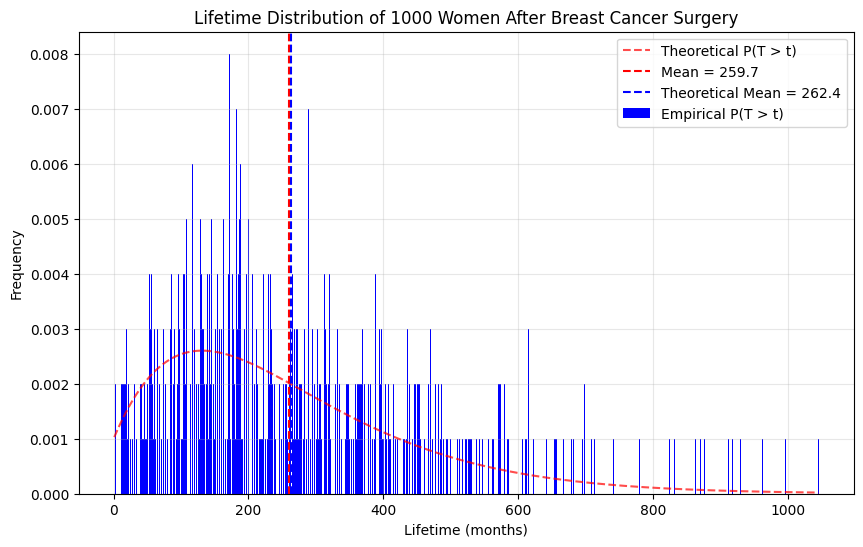

In [33]:
import numpy as np

pi = np.array([1, 0, 0, 0])

Ps = P[0:4, 0:4]

I = np.eye(4)

ps = P[:4, 4]

E = pi @ np.linalg.inv(np.eye(4) - Ps) @ np.ones(4)

print("\nTheoretical Expected lifetime", E)
print("\nEstimated Expected lifetime", death_times.mean())

t_max = int(np.max(death_times))
t_vals = np.arange(1, t_max + 1)

P_t = np.array([pi @ np.linalg.matrix_power(Ps, t) @ ps for t in t_vals])
counts = np.bincount(death_times)
pmf_emp = counts[1:t_max+1] / len(death_times)

plt.figure(figsize=(10, 6))
plt.bar(t_vals, pmf_emp, label='Empirical P(T > t)', color='blue')
plt.plot(t_vals, P_t, '--', color='red', alpha=0.7, label='Theoretical P(T > t)')
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Lifetime Distribution of 1000 Women After Breast Cancer Surgery')
plt.axvline(death_times.mean(), color='red', linestyle='--', label=f'Mean = {death_times.mean():.1f}')
plt.axvline(E, color='blue', linestyle='--', label=f'Theoretical Mean = {E:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 4

In [34]:
np.random.seed(42)
lifetimes = []
n_woman = 0

while n_woman < 1000:
    current_state = 0 
    time = 0
    ever_local_recurrence = False
    ever_distant_recurrence = False
    
    while True:
        if current_state == 1 and time <= 12:
            ever_local_recurrence = True
        if current_state == 3 and time <= 12:
            ever_distant_recurrence = True
            
        next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
        time += 1
        
        if next_state == 4 and time > 12 and (ever_local_recurrence or ever_distant_recurrence):
            n_woman += 1
            lifetimes.append(time)
            break
        if time > 12 and not (ever_local_recurrence or ever_distant_recurrence):
            break
            
        current_state = next_state

lifetimes = np.array(lifetimes)
print(f"Expected lifetime: {lifetimes.mean():.2f} months")
print(f"Sample size: {len(lifetimes)}")

Expected lifetime: 165.53 months
Sample size: 1000


## Task 5

In [35]:
np.random.seed(42)
n_simulations = 100
n_women = 200
fraction_results = []
mean_lifetime_results = []
for _ in range(n_simulations):
    deaths_within_350 = 0
    lifetimes = []
    for _ in range(n_women):
        current_state = 0 
        time = 0
        ever_local_recurrence = False
        
        while True:
                
            next_state = np.random.choice([0, 1, 2, 3, 4], p=P[current_state])
            
            time += 1
            if next_state == 4 and time <= 350:
                deaths_within_350 += 1
                lifetimes.append(time)
                break
            elif next_state == 4:
                lifetimes.append(time)
                break
            current_state = next_state
            

    fraction = deaths_within_350 / n_women
    fraction_results.append(fraction)
    mean_lifetime_results.append(np.mean(lifetimes))

Y = np.array(fraction_results)
X = np.array(mean_lifetime_results)

# Crude monte carlo
theta_crude = np.mean(Y)
var_crude = np.var(Y, ddof=1)

X_mu = 265.04

cov_YX = np.cov(Y, X, ddof=1)[0, 1]
var_X = np.var(X, ddof=1)
beta = cov_YX / var_X

Z = Y - beta * (X - X_mu)
theta_cv = np.mean(Z)
var_cv = np.var(Z, ddof=1)

variance_reduction = (var_crude - var_cv) / var_crude

print(f"Crude MC estimator:      {theta_crude:.4f}")
print(f"Control Variate estimator: {theta_cv:.4f}")
print(f"Variance of Y (crude):     {var_crude:.6f}")
print(f"Variance of Z (CV):        {var_cv:.6f}")
print(f"Variance reduction:        {variance_reduction:.2%}")

Crude MC estimator:      0.7375
Control Variate estimator: 0.7315
Variance of Y (crude):     0.001301
Variance of Z (CV):        0.000309
Variance reduction:        76.25%


## Task 6
No code

# Part 2

## Task 7

Running simulation number: 1
Running simulation number: 2
Running simulation number: 3
Running simulation number: 4
Running simulation number: 5
Running simulation number: 6
Running simulation number: 7
Running simulation number: 8
Running simulation number: 9
Running simulation number: 10
Running simulation number: 11
Running simulation number: 12
Running simulation number: 13
Running simulation number: 14
Running simulation number: 15
Running simulation number: 16
Running simulation number: 17
Running simulation number: 18
Running simulation number: 19
Running simulation number: 20
Running simulation number: 21
Running simulation number: 22
Running simulation number: 23
Running simulation number: 24
Running simulation number: 25
Running simulation number: 26
Running simulation number: 27
Running simulation number: 28
Running simulation number: 29
Running simulation number: 30
Running simulation number: 31
Running simulation number: 32
Running simulation number: 33
Running simulation 

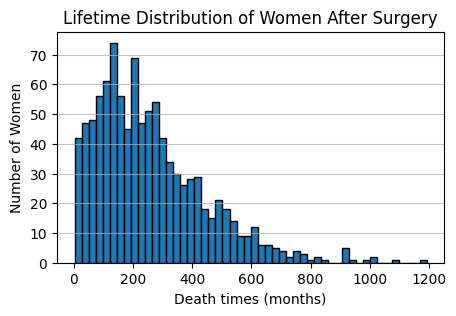

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.distributions import chi2

np.random.seed(5)

outer_means = []
outer_stds = []

# Transition-rate matrix
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001], 
              [0, -0.014, 0.005, 0.004, 0.005], 
              [0, 0, -0.008, 0.003, 0.005], 
              [0, 0, 0, -0.009, 0.009], 
              [0, 0, 0, 0, 0]])


# Bootstrap loop for estimating the mean lifetime and its confidence interval
for i in range(100):
    print("Running simulation number:", i+1)

    # Number of women to simulate
    N = 1000
    # List to store death times for all women
    death_times = np.zeros(N, dtype=int)

    # I simulate the entire state-history of each woman at a time

    counter = 0

    for i in range(N):
        
        t = 0
        state = 0

        # list for storing the state history of this woman
        state_hist = []
        # list for storing the time history of events for this woman
        time_hist = []

        while state != 4:
                # Sojourn time in current state
                sojourn_time = np.random.exponential(scale= -1 / Q[state, state])
                # Jumping to next event
                t += sojourn_time

                # Transition to next state 
                transition_probs = Q[state] / - Q[state, state]
                # but we cant transition to the same state, so we set that probability to zero
                transition_probs[state] = 0
                # Determine the next state
                next_state = np.random.choice(num_states, p=transition_probs) 
                
                # Update state
                state = next_state

                # Logging state and time history for this woman
                state_hist.append(state)
                time_hist.append(t)

                if state == 4:
                    # logging the death time for this woman
                    death_times[i] = t

                    # mask for times more than 30.5 months
                    mask = np.array(time_hist) > 30.5
                    # check if there is distant metastasis (state 2 or 3) within the first 30.5 months
                    if np.any(np.isin(np.array(state_hist)[mask], [2, 3])):
                        counter += 1
    
    # Store the mean and standard deviation for this bootstrap iteration
    outer_means.append(np.mean(death_times))
    outer_stds.append(np.std(death_times, ddof=1))

# Mean of lifetime
mean_lifetime = np.mean(outer_means)
# Standard deviation for mean lifetime
std_lifetime = np.mean(outer_stds)
# 95% confidence interval for mean lifetime
ci_lower = np.percentile(outer_means, 2.5)
ci_upper = np.percentile(outer_means, 97.5)
# 95% confidence interval for standard deviation of lifetime
ci_lower_std = np.percentile(outer_stds, 2.5)
ci_upper_std = np.percentile(outer_stds, 97.5)

print(f"Mean lifetime: {mean_lifetime:.2f} months ~ {mean_lifetime / 12:.2f} years")
print(f"Standard deviation of lifetime: {std_lifetime:.2f} months ~ {std_lifetime / 12:.2f} years\n")
print(f"95% confidence interval for mean lifetime: [{ci_lower:.2f}, {ci_upper:.2f}] months ~ [{ci_lower / 12:.2f}, {ci_upper / 12:.2f}] years")
print(f"95% confidence interval for standard deviation of lifetime: [{ci_lower_std:.2f}, {ci_upper_std:.2f}] months ~ [{ci_lower_std / 12:.2f}, {ci_upper_std / 12:.2f}] years\n")

print(f"Fraction of women with distant metastasis within first 30.5 months: {counter / N:.2f}")

# Plot the lifetime distribution
plt.figure(figsize=(5, 3))
plt.hist(death_times, bins=50, edgecolor='black')
plt.title('Lifetime Distribution of Women After Surgery')
plt.xlabel('Death times (months)')
plt.ylabel('Number of Women')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Task 8

In [37]:
#Emperical distribution function
def F_n(x, obs):
    # number of observations
    n = np.size(obs)
    #Computing F_n by number of observations smaller that x for each x
    vals = np.zeros(np.size(x)) 
    for i in range(len(x)):
        vals[i] = (1/n) * np.sum(obs <= x[i])
    return vals

In [38]:
### Construct parameters for Continuous time phase-type distribution
import scipy as sp
#Submatrix of Q, minus last row and col
Q_s = Q[:-1,:-1].copy()
#Initial state, minus last element
p_0 = np.array([1,0,0,0])

def cdf_CTPT(t, p_0=p_0, Q_s=Q_s):
    d = np.shape(Q_s)[0]
    n = np.size(t)
    vals = np.zeros(n)
    for i in range(n):
        mat_exp = sp.linalg.expm(Q_s*t[i])
        mat_prod = p_0 @ mat_exp @ np.ones(d)
        vals[i] = 1 - mat_prod
    return vals

### Compute cdf vals
tgrid = np.linspace(0, 1200, num=1000)
#cdf_ctpt_vals = np.array([ cdf_CTPT(t) for t in tgrid])
cdf_ctpt_vals = cdf_CTPT(tgrid)
cdf_emp_vals = F_n(x=tgrid, obs=death_times)

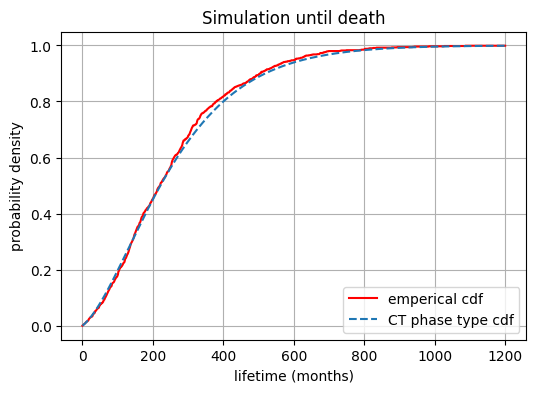

In [39]:
### Visualising with theoretical cdf
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    cdf_emp_vals,
    label="emperical cdf",
    color='red'
)

ax.plot(
    tgrid,
    cdf_ctpt_vals,
    label="CT phase type cdf",
    linestyle='--'
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability density')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

In [40]:
### KS test af GOF test

print("Own computation")
# Computing KS test statistics (non-adjusted)
D_n = np.max(np.abs(cdf_emp_vals-cdf_ctpt_vals))
print(f"D_n: {D_n:.4g}")

# Computing adjusted test statistic
D_n_adj = (np.sqrt(N) + 0.12 +  0.11/np.sqrt(N))*D_n
print(f"adjusted D_n: {D_n_adj:.4g}")

# Computing the p-value form the cdf
cdf_val = sp.stats.kstwo.cdf(D_n, n=N)
p_val = 1-cdf_val
print(f"p_val: {p_val:.4g}")

D_n_kstest, p_val_kstest = sp.stats.kstest(rvs=death_times, cdf=cdf_CTPT)
print("Using kstest from scipy.stats")
print(f"D_n_kstest: {D_n_kstest:.4g}")
print(f"p_val_kstest: {p_val_kstest:.4g}")

Own computation
D_n: 0.03653
adjusted D_n: 1.16
p_val: 0.1353
Using kstest from scipy.stats
D_n_kstest: 0.03762
p_val_kstest: 0.1149


## Task 9

In [41]:
### Compute missing diagonal values of new Q
row0 = np.array([0.0025, 0.00125, 0,     0.001]) 
row1 = np.array([0, 0, 0.002, 0.005])
row2 = np.array([0, 0, 0.003, 0.005])
row3 = np.array([0, 0, 0, 0.009])
row4 = np.array([0, 0, 0, 0])
rows = [row0, row1, row2, row3, row4]
diagonals = np.array([0, 0, 0, 0, 0])
for i in range(len(diagonals)):
    diagonal = -np.sum(rows[i])
    rows[i] = np.insert(rows[i], i, diagonal)

Qtreat = np.array(rows)
print("Q treatment:")
print(Qtreat)

Q treatment:
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]


In [42]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t9 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list = []
#Initialise list for logging times at which transitions happens
time_hist_list = []
#Initialise passed criterium counter
crit_pass_count = 0

print("Beginning simulation...")
S = np.array([0,1,2,3,4])
### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability (use copy due to how python lists work)
        prob_trans = Qtreat[state,:].copy() / rate_soj
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t9.append(lifetime)
    state_hist_list.append(state_hist)
    time_hist_list.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [43]:
### Check results
mean_sample_t9 = np.mean(lifetime_list_t9)
print(f"Expected lifetime of women:\n{mean_sample_t9:.2f} months\n {mean_sample_t9/12:.2f} years")

print("Length of lifetimes:", len(lifetime_list_t9))
print(f"Number of women simulated: {women_all_count}")

print("first vals of lifetimes:")
print(lifetime_list_t9[:5])
print("Example of state_hist:")
print(state_hist_list[1])
print("Example of time_hist:")
print(time_hist_list[1])

Expected lifetime of women:
365.68 months
 30.47 years
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[np.float64(87.65246629389691), np.float64(234.60341713538537), np.float64(105.77772846316442), np.float64(407.31955117604394), np.float64(16.79172051481303)]
Example of state_hist:
[0, np.int64(2), np.int64(4)]
Example of time_hist:
[0, np.float64(230.92303612308476), np.float64(234.60341713538537)]


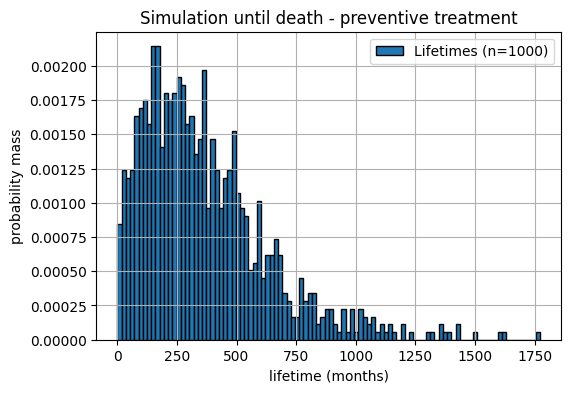

In [44]:
### Visualising
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    lifetime_list_t9, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death - preventive treatment')
ax.legend()
ax.grid()

plt.show()

In [45]:
### Kaplan-Meier estimator
def DiedWomen(t, obs):
    vals = np.zeros(np.size(t)) 
    for i in range(len(t)):
        vals[i] = np.sum(obs <= t[i])
    return vals

def KaplamMeierEstimator(t, obs, d=DiedWomen):
    N = len(obs)
    return (N-d(t=t, obs=obs))/N 

tgrid = np.linspace(0, 2000, num=2001)
KM_vals_t7 = KaplamMeierEstimator(t=tgrid, obs=death_times)
KM_vals_t9 = KaplamMeierEstimator(t=tgrid, obs=lifetime_list_t9)

print(np.shape(KM_vals_t9))

(2001,)


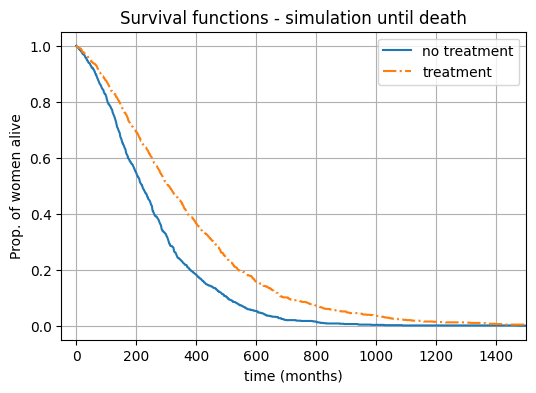

In [46]:
### Visualising the two survival functions
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    KM_vals_t7,
    label="no treatment",
    )

ax.plot(
    tgrid,
    KM_vals_t9,
    label="treatment",
    linestyle='-.'
    )

ax.set_xlabel('time (months)')
ax.set_ylabel('Prop. of women alive')
ax.set_title('Survival functions - simulation until death')
ax.legend()
ax.grid()
ax.set_xlim(-50,1500)

plt.show()

## Task 10

In [47]:
from scipy.stats import logrank

result = logrank(KM_vals_t7, KM_vals_t9)
print("Log-rank test results:", result)

Log-rank test results: LogRankResult(statistic=np.float64(9.298568199618419), pvalue=np.float64(1.423496201789992e-20))


## Task 11
No code

# Part 3

## Task 12

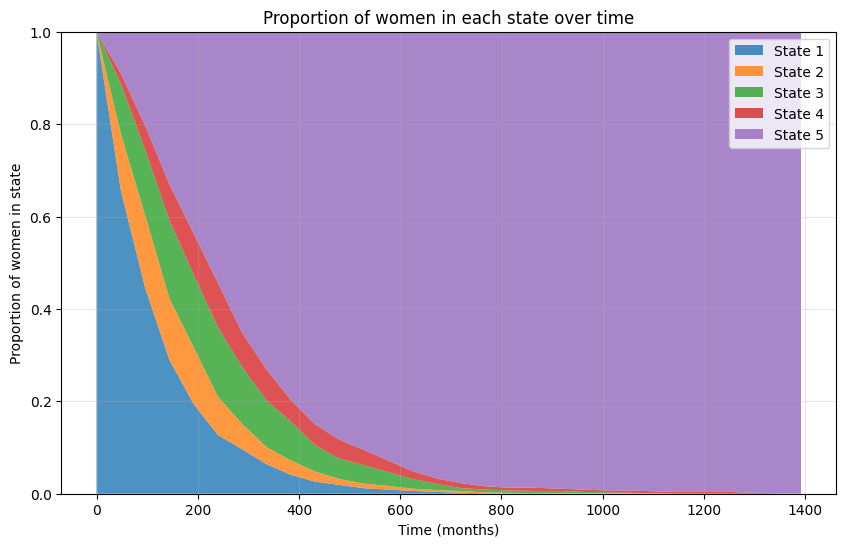

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

np.random.seed(42)

Q_true = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

n_women = 1000
death_state = 4
interval = 48

observations = []

for i in range(n_women):
    current_state = 0
    time = 0.0
    times = []
    states = []

    while current_state != death_state:
        rate = -Q_true[current_state, current_state]
        state_time = np.random.exponential(1 / rate)
        time += state_time

        p = Q_true[current_state].copy()
        p[current_state] = 0.0
        p = p / p.sum()
        next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

        times.append(time)
        states.append(next_state)
        current_state = next_state

    obs = [0]
    t = interval
    while True:
        idx = np.searchsorted(times, t, side='right') - 1
        if idx < 0:
            state_at_t = 0
        else:
            state_at_t = states[idx]
        obs.append(state_at_t)
        if state_at_t == death_state:
            break
        t += interval

    observations.append(obs)

# Pad every observation list with death state so they all have the same length
max_length = max(len(obs) for obs in observations)
for obs in observations:
    while len(obs) < max_length:
        obs.append(death_state)

# Build state proportions
state_proportions = np.zeros((5, max_length))
for obs in observations:
    for t, state in enumerate(obs):
        state_proportions[state, t] += 1
state_proportions /= n_women

# x-axis must be the actual time points in months
time_points = np.arange(0, max_length * interval, interval)

plt.figure(figsize=(10, 6))
plt.stackplot(
    time_points,
    state_proportions[0],
    state_proportions[1],
    state_proportions[2],
    state_proportions[3],
    state_proportions[4],
    labels=[f'State {i}' for i in range(1,6)],
    alpha=0.8
)
plt.xlabel('Time (months)')
plt.ylabel('Proportion of women in state')
plt.title('Proportion of women in each state over time')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

## Task 13

Iteration 1: max diff = 0.021685
Iteration 2: max diff = 0.002968
Iteration 3: max diff = 0.001940
Iteration 4: max diff = 0.000643
Iteration 5: max diff = 0.000426
Iteration 6: max diff = 0.000351
Iteration 7: max diff = 0.000272
Iteration 8: max diff = 0.000254
Iteration 9: max diff = 0.000286
Iteration 10: max diff = 0.000279
Iteration 11: max diff = 0.000549
Iteration 12: max diff = 0.000544
Iteration 13: max diff = 0.000405
Iteration 14: max diff = 0.000227
Iteration 15: max diff = 0.000505
Iteration 16: max diff = 0.000365
Iteration 17: max diff = 0.000358
Iteration 18: max diff = 0.000419
Iteration 19: max diff = 0.000187
Iteration 20: max diff = 0.000138
Iteration 21: max diff = 0.000270
Iteration 22: max diff = 0.000333
Iteration 23: max diff = 0.000340
Iteration 24: max diff = 0.000333
Iteration 25: max diff = 0.000246
Iteration 26: max diff = 0.000691
Iteration 27: max diff = 0.000558
Iteration 28: max diff = 0.000369
Iteration 29: max diff = 0.000426
Iteration 30: max diff 

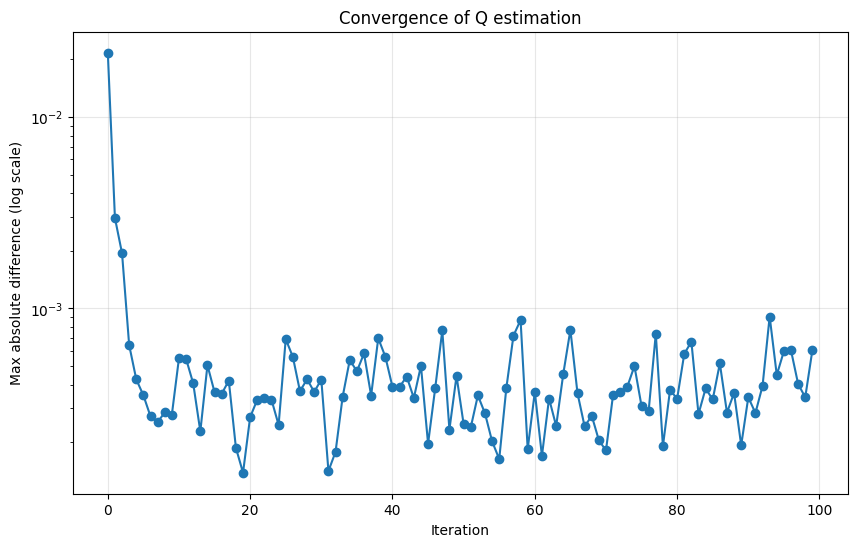

In [49]:
# Randomly inititate Q_est
Q_est = np.random.rand(5, 5)*0.01
for i in range(5):
    Q_est[i, i] = -Q_est[i].sum() + Q_est[i, i]

max_iter = 100
tol = 1e-4
diffs = []
for iteration in range(max_iter):
    N = np.zeros((5, 5))
    S = np.zeros(5)

    for obs in observations:
        for k in range(len(obs) - 1):
            start = obs[k]
            end   = obs[k + 1]

            if start == death_state:
                S[death_state] += interval
                continue

            accepted = False
            while not accepted:
                current_state = start
                time = 0.0
                jump_times = []
                jump_states = []

                while time < interval and current_state != death_state:
                    rate = -Q_est[current_state, current_state]
                    state_time = np.random.exponential(1 / rate)

                    if time + state_time > interval:
                        break

                    time += state_time
                    p = Q_est[current_state].copy()
                    p[current_state] = 0.0
                    p = p / p.sum()
                    next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

                    jump_times.append(time)
                    jump_states.append(next_state)
                    current_state = next_state

                if current_state == end:
                    accepted = True

            prev_t = 0.0
            current = start

            for t, s in zip(jump_times, jump_states):
                S[current] += t - prev_t
                N[current, s] += 1
                current = s
                prev_t = t

            S[current] += interval - prev_t

    Q_new = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            if i != j and S[i] > 0:
                Q_new[i, j] = N[i, j] / S[i]
        Q_new[i, i] = -Q_new[i].sum()

    diff = np.max(np.abs(Q_new - Q_est))
    diffs.append(diff)
    print(f"Iteration {iteration + 1}: max diff = {diff:.6f}")

    if diff < tol:
        print("Converged!")
        Q_est = Q_new
        break

    Q_est = Q_new

print("\nEstimated Q:")
print(Q_est)
print("\nTrue Q:")
print(Q_true)

plt.figure(figsize=(10, 6))
plt.plot(diffs, marker='o')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Max absolute difference (log scale)')
plt.title('Convergence of Q estimation')
plt.grid(True, alpha=0.3)
plt.show()